In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

import joblib
import os


In [2]:
df = pd.read_csv("../../data/all_data.csv")

In [3]:
df.head(3)

,Timestamp,PID,Process_Name,CPU_Usage_%,Mem_Usage_MB,Power_W,id,timestamp,pid,name,cpu,ram,process_key,occurrence_count,timestamp_parsed,last_seen
0,2025-12-06T16:46:25.124639+00:00,401.0,loginwindow,0.0,49.53125,0.0,NaN,NaN,-1,NaN,NaN,NaN,-1||nan,1,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,6ef44761-07e6-4271-8ff0-654372f560c6,2025-12-06T16:56:35.962203+00:00,401,loginwindow,0.0,47.234375,401||loginwindow,8,2025-12-06 16:56:35.962203+00:00,2025-12-06 17:03:30.943316+00:00
2,NaN,NaN,NaN,NaN,NaN,NaN,69879540-25db-4781-a645-180ce95c22be,2025-12-06T16:56:35.962203+00:00,570,distnoted,0.0,7.500000,570||distnoted,8,2025-12-06 16:56:35.962203+00:00,2025-12-06 17:03:30.943316+00:00


In [4]:
# -----------------------------------------------------------
# 2. Convert timestamps to Python datetime
# -----------------------------------------------------------
df["timestamp_parsed"] = pd.to_datetime(df["timestamp_parsed"], errors="coerce")
df["last_seen"] = pd.to_datetime(df["last_seen"], errors="coerce")

# If engineered features are not already there, create them
if "hour" not in df.columns:
    df["hour"] = df["timestamp_parsed"].dt.hour
if "day" not in df.columns:
    df["day"] = df["timestamp_parsed"].dt.day
if "weekday" not in df.columns:
    df["weekday"] = df["timestamp_parsed"].dt.weekday
if "time_alive" not in df.columns:
    df["time_alive"] = (df["last_seen"] - df["timestamp_parsed"]).dt.total_seconds()

In [5]:
# -----------------------------------------------------------
# 3. Select numeric features
# -----------------------------------------------------------
X = df.select_dtypes(include=[np.number]).copy()
print("Numeric feature columns used:")
print(X.columns.tolist())
print("Feature matrix shape:", X.shape)

Numeric feature columns used:
['PID', 'CPU_Usage_%', 'Mem_Usage_MB', 'Power_W', 'pid', 'cpu', 'ram', 'occurrence_count', 'hour', 'day', 'weekday', 'time_alive']
Feature matrix shape: (3626, 12)


In [6]:
# -----------------------------------------------------------
# 4. Handle missing values
# -----------------------------------------------------------
imputer = SimpleImputer(strategy="median")
X_cleaned = imputer.fit_transform(X)

In [7]:
# -----------------------------------------------------------
# 5. Train/Test Split (unsupervised, but we still use split to check stability)
# -----------------------------------------------------------
X_train, X_test = train_test_split(
    X_cleaned,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size : {X_test.shape}")


Train set size: (2900, 12)
Test set size : (726, 12)


In [8]:
# -----------------------------------------------------------
# 6. Scale features
# -----------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
# -----------------------------------------------------------
# 7. Train IsolationForest
# -----------------------------------------------------------
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,     # % of anomalies expected
    random_state=42,
    bootstrap=True
)

iso.fit(X_train_scaled)

IsolationForest(bootstrap=True, contamination=0.01, n_estimators=200,
                random_state=42)

In [10]:
# -----------------------------------------------------------
# 8. Simple anomaly detection report
#    -1 = anomaly, 1 = normal
# -----------------------------------------------------------
train_preds = iso.predict(X_train_scaled)
test_preds = iso.predict(X_test_scaled)

n_train_anom = np.sum(train_preds == -1)
n_test_anom = np.sum(test_preds == -1)

print("\n=== IsolationForest Anomaly Summary ===")
print(f"Train anomalies: {n_train_anom} / {len(train_preds)} "
      f"({n_train_anom/len(train_preds)*100:.2f}%)")
print(f"Test anomalies : {n_test_anom} / {len(test_preds)} "
      f"({n_test_anom/len(test_preds)*100:.2f}%)")

# A simple "score" (higher = fewer anomalies, purely heuristic)
train_score = iso.score_samples(X_train_scaled).mean()
test_score = iso.score_samples(X_test_scaled).mean()
print(f"\nAverage anomaly score (higher means more normal):")
print(f"  Train: {train_score:.4f}")
print(f"  Test : {test_score:.4f}")



=== IsolationForest Anomaly Summary ===
Train anomalies: 29 / 2900 (1.00%)
Test anomalies : 8 / 726 (1.10%)

Average anomaly score (higher means more normal):
  Train: -0.4445
  Test : -0.4466


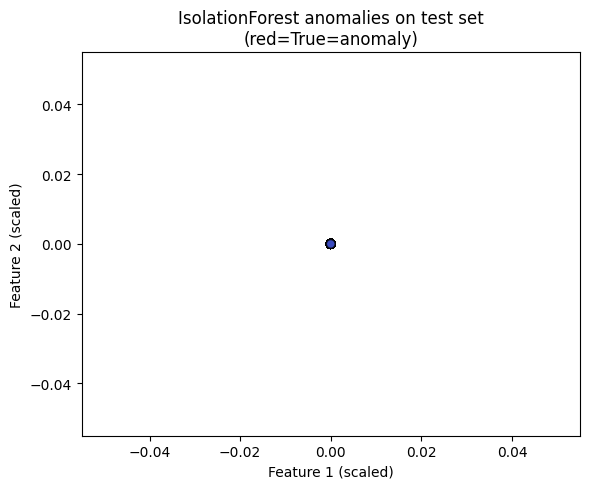

In [11]:
# -----------------------------------------------------------
# 9. (Optional) Visual check using first 2 features after scaling
# -----------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(
    X_test_scaled[:, 0],
    X_test_scaled[:, 1],
    c=(test_preds == -1),
    cmap="coolwarm",
    s=40,
    alpha=0.7,
    edgecolors="k",
)
plt.title("IsolationForest anomalies on test set\n(red=True=anomaly)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.tight_layout()
plt.show()

In [12]:
# -----------------------------------------------------------
# 10. Save model and preprocessors
# -----------------------------------------------------------
os.makedirs("./builds", exist_ok=True)

joblib.dump(iso, "./builds/isolation_forest_model.pkl")
  
print("\n✅ IsolationForest model and preprocessors saved in ./builds/")


✅ IsolationForest model and preprocessors saved in ./builds/
